# Relevant Links
Github: https://github.com/magloev/magloevIND320
Streamlit app: https://magloevind320.streamlit.app/

# AI Usage
for this project etc..

# Log
Started with some data exploration of the dataset reservoirs.csv. Found fill_level, stored_energy_TWh, fill_level_prev_week and fill_level_change to be relevant ones to show on the plot. Normalized them so that all values would fit reasonably in the plot. Decided to show only the total national data for now to make it simpler.

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv('../data/reservoirs.csv')

#Renaming the columns to reasonable English equivalents
df = df.rename(columns= {
    "dato_Id" : "date",
    "omrType" : "area_type",
    "omrnr"   : "area_id",
    "iso_aar" : "iso_year",
    "iso_uke"  : "iso_week",
    "fyllingsgrad" : "fill_level",
    "kapasitet_TWh" : "capacity_TWh",
    "fylling_TWh" : "stored_energy_TWh",
    "neste_Publiseringsdato" : "next_publication_date", 
    "fyllingsgrad_forrige_uke" : "fill_level_prev_week",
    "endring_fyllingsgrad" : "fill_level_change" })

#Sort the data by date
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by="date")

df.head(20)

count    14877.000000
mean        26.405929
std         15.017910
min          1.000000
25%         13.000000
50%         26.000000
75%         39.000000
max         53.000000
Name: iso_week, dtype: float64

In [12]:
#Relevant columns to plot
columns = [
    "fill_level",
    "stored_energy_TWh",
    "fill_level_prev_week",
    "fill_level_change"
]

#Select the national data
df_no = df[
    (df["area_type"] == "NO")
].copy()

df_no = df_no.sort_values("date")
df_no_normalized = df_no.copy()



<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

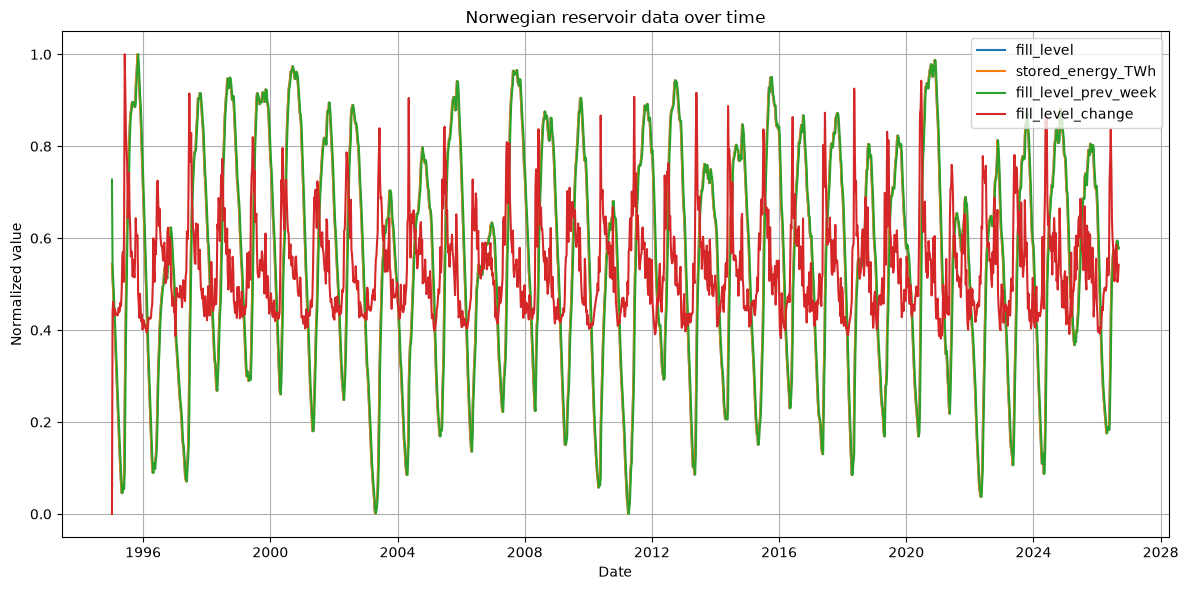

In [13]:
#Normalizing columns with min-max scaling, to plot them on the same graph.
for column in columns:
    df_no_normalized[column] = (
        (df_no[column] - df_no[column].min())
        / (df_no[column].max() - df_no[column].min())
    )

    plt.figure(figsize=(12, 6))

for column in columns:
    plt.plot(
        df_no_normalized["date"],
        df_no_normalized[column],
        label=column
    )


plt.title("Norwegian reservoir data over time")
plt.xlabel("Date")
plt.ylabel("Normalized value")
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()
